In [5]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

In [7]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

In [72]:
# 파일 읽어오기
data = pd.read_csv(path + 'data.csv')

In [66]:
data.corr(numeric_only=True)

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction,Age_Group
Gender,1.000000,0.012823,-0.005711,0.002532,0.001654,0.000102,0.012108,0.002427,0.008076,0.011073,...,-0.015142,-0.024907,-0.007012,0.007671,-0.003719,0.032980,0.006630,0.005075,0.000929,-0.006695
Customer Type,0.012823,1.000000,0.339880,0.121494,-0.073596,0.237610,-0.085740,0.087058,-0.104907,0.019614,...,0.058952,0.122663,-0.029224,-0.011477,-0.031741,0.173514,-0.000594,-0.001434,0.140496,0.331405
Age,-0.005711,0.339880,1.000000,-0.084649,-0.126950,0.102577,-0.030635,0.027869,-0.033216,0.012046,...,0.113336,0.193321,0.022102,0.048655,0.026232,0.052826,0.002952,0.001523,0.099842,0.975837
Type of Travel,0.002532,0.121494,-0.084649,1.000000,0.451849,-0.214832,0.007253,0.160210,-0.002423,-0.026265,...,-0.162772,-0.170188,-0.109974,-0.079218,-0.100007,-0.161670,-0.017631,-0.021312,-0.398433,-0.086027
Class,0.001654,-0.073596,-0.126950,0.451849,1.000000,-0.403363,0.161151,0.059503,0.002898,-0.008886,...,-0.273800,-0.261472,-0.248778,-0.214311,-0.243471,-0.120454,-0.006728,-0.002269,-0.302326,-0.123847
Flight Distance,0.000102,0.237610,0.102577,-0.214832,-0.403363,1.000000,-0.109623,-0.009694,-0.020831,0.005641,...,0.122197,0.154842,0.105459,0.092419,0.088419,0.103934,0.010970,0.004770,0.161103,0.103375
Inflight wifi service,0.012108,-0.085740,-0.030635,0.007253,0.161151,-0.109623,1.000000,0.546917,0.778830,0.552926,...,0.031412,0.059225,0.047033,-0.024812,0.045278,0.043151,-0.000301,0.001509,0.148719,-0.029338
Departure/Arrival time convenient,0.002427,0.087058,0.027869,0.160210,0.059503,-0.009694,0.546917,1.000000,0.575007,0.646653,...,0.030169,0.017402,0.030681,0.017224,0.035354,0.003660,0.000813,-0.000502,-0.028384,0.022824
Ease of Online booking,0.008076,-0.104907,-0.033216,-0.002423,0.002898,-0.020831,0.778830,0.575007,1.000000,0.591288,...,0.047037,0.078589,0.062982,0.012170,0.064103,-0.005627,-0.001273,-0.002566,0.105956,-0.032347
Gate location,0.011073,0.019614,0.012046,-0.026265,-0.008886,0.005641,0.552926,0.646653,0.591288,1.000000,...,-0.009119,-0.000542,-0.007981,-0.013825,-0.006491,0.003114,-0.000421,-0.000641,0.003805,0.011956


In [73]:
corr = data.corr(numeric_only=True)

# 1차원 시리즈로 변환
corr_unstack = corr.unstack()

# 0.7 이상이고 자기 자신(1.0)이 아닌 값만 필터링
high_corr_list = corr_unstack[(corr_unstack >= 0.7) & (corr_unstack < 1.0)]

# 내림차순 정렬
print(high_corr_list.sort_values(ascending=False))

Age                         Age_Group                     0.975837
Age_Group                   Age                           0.975837
Arrival Delay in Minutes    Departure Delay in Minutes    0.954245
Departure Delay in Minutes  Arrival Delay in Minutes      0.954245
Inflight wifi service       Ease of Online booking        0.778830
Ease of Online booking      Inflight wifi service         0.778830
dtype: float64


In [74]:
data2 = data.drop('Age' ,axis=1)
data2 = data.drop('Arrival Delay in Minutes' ,axis=1)
data2 = data.drop('Ease of Online booking' ,axis=1)

In [75]:
data2.columns.unique()

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Gate location', 'Food and drink',
       'Online boarding', 'Seat comfort', 'Inflight entertainment',
       'On-board service', 'Leg room service', 'Baggage handling',
       'Checkin service', 'Inflight service', 'Cleanliness',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'Satisfaction', 'Age_Group'],
      dtype='object')

In [76]:
# 설문 범주 정의
categories = [0, 1, 2, 3, 4, 5]

# 가변수화 대상 변수
dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Gate location',
             'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
             'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

# Category 형 변수로 변환
for col in dumm_cols:
    data2[col] = pd.Categorical(data2[col], categories=categories)

# 가변수화
data2 = pd.get_dummies(data2, columns=dumm_cols , drop_first=True, dtype=int)

# 확인
data2.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction,Age_Group,...,Inflight service_1,Inflight service_2,Inflight service_3,Inflight service_4,Inflight service_5,Cleanliness_1,Cleanliness_2,Cleanliness_3,Cleanliness_4,Cleanliness_5
0,1,1,35.0,0,1,349,0,0.0,1,30,...,1,0,0,0,0,0,0,0,0,1
1,0,1,40.0,0,0,920,10,3.0,1,40,...,0,0,0,1,0,0,0,0,0,1
2,0,1,52.0,0,0,3979,21,7.0,1,50,...,0,0,0,1,0,0,0,0,1,0
3,1,1,47.0,0,1,141,142,158.0,1,40,...,0,0,0,1,0,0,0,0,0,1
4,1,1,33.0,0,0,3153,0,0.0,1,30,...,0,1,0,0,0,0,0,1,0,0


In [77]:
target ='Satisfaction'

x = data2.drop(target, axis=1)
y = data2.loc[:,target]


In [78]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# X: 피처 데이터, y: 타겟 레이블
# sampling_strategy='auto'는 다수 클래스를 소수 클래스 개수와 동일하게 맞춤
rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)
x, y = rus.fit_resample(x, y)

# 결과 확인
print(f"원래 타겟 분포: \n{y.value_counts()}")
print(f"언더샘플링 후 분포: \n{pd.Series(y).value_counts()}")

원래 타겟 분포: 
Satisfaction
0    1985
1    1985
Name: count, dtype: int64
언더샘플링 후 분포: 
Satisfaction
0    1985
1    1985
Name: count, dtype: int64


In [81]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.1, stratify=y, random_state=1)

In [82]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [83]:
from tensorflow.keras.regularizers import l1, l2

In [88]:
clear_session()

#fature수
nfeatures = x.shape[1]

#모델 선언
model5 = Sequential([
    Input((nfeatures, )),
    Dense(32, activation='relu', kernel_regularizer=l2(0.05)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.05)),
    Dense(16, activation='relu', kernel_regularizer=l2(0.05)),
    Dense(1, activation='sigmoid')
])

model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,001 (15.63 KB)

 Trainable params: 4,001 (15.63 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
from tensorflow.keras.callbacks import EarlyStopping

# 학습 설정
model5.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=10, restore_best_weights=True, verbose=1)

# 학습
hist = model5.fit(x_train, y_train, epochs=100, validation_split=0.2, callbacks=[es], verbose=1).history

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.8263 - val_loss: 2.4408
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7091 - val_loss: 1.1797
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9124 - val_loss: 0.7360
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6271 - val_loss: 0.5708
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5221 - val_loss: 0.5076
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4769 - val_loss: 0.4780
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4556 - val_loss: 0.4743
Epoch 8/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4431 - val_loss: 0.4628
Epoch 9/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4326 - val_loss: 0.4471
Epoch 10/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4251 - val_loss: 0.4396
Epoch 11/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4187 - val_loss: 0.4346
Epoch 12/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4

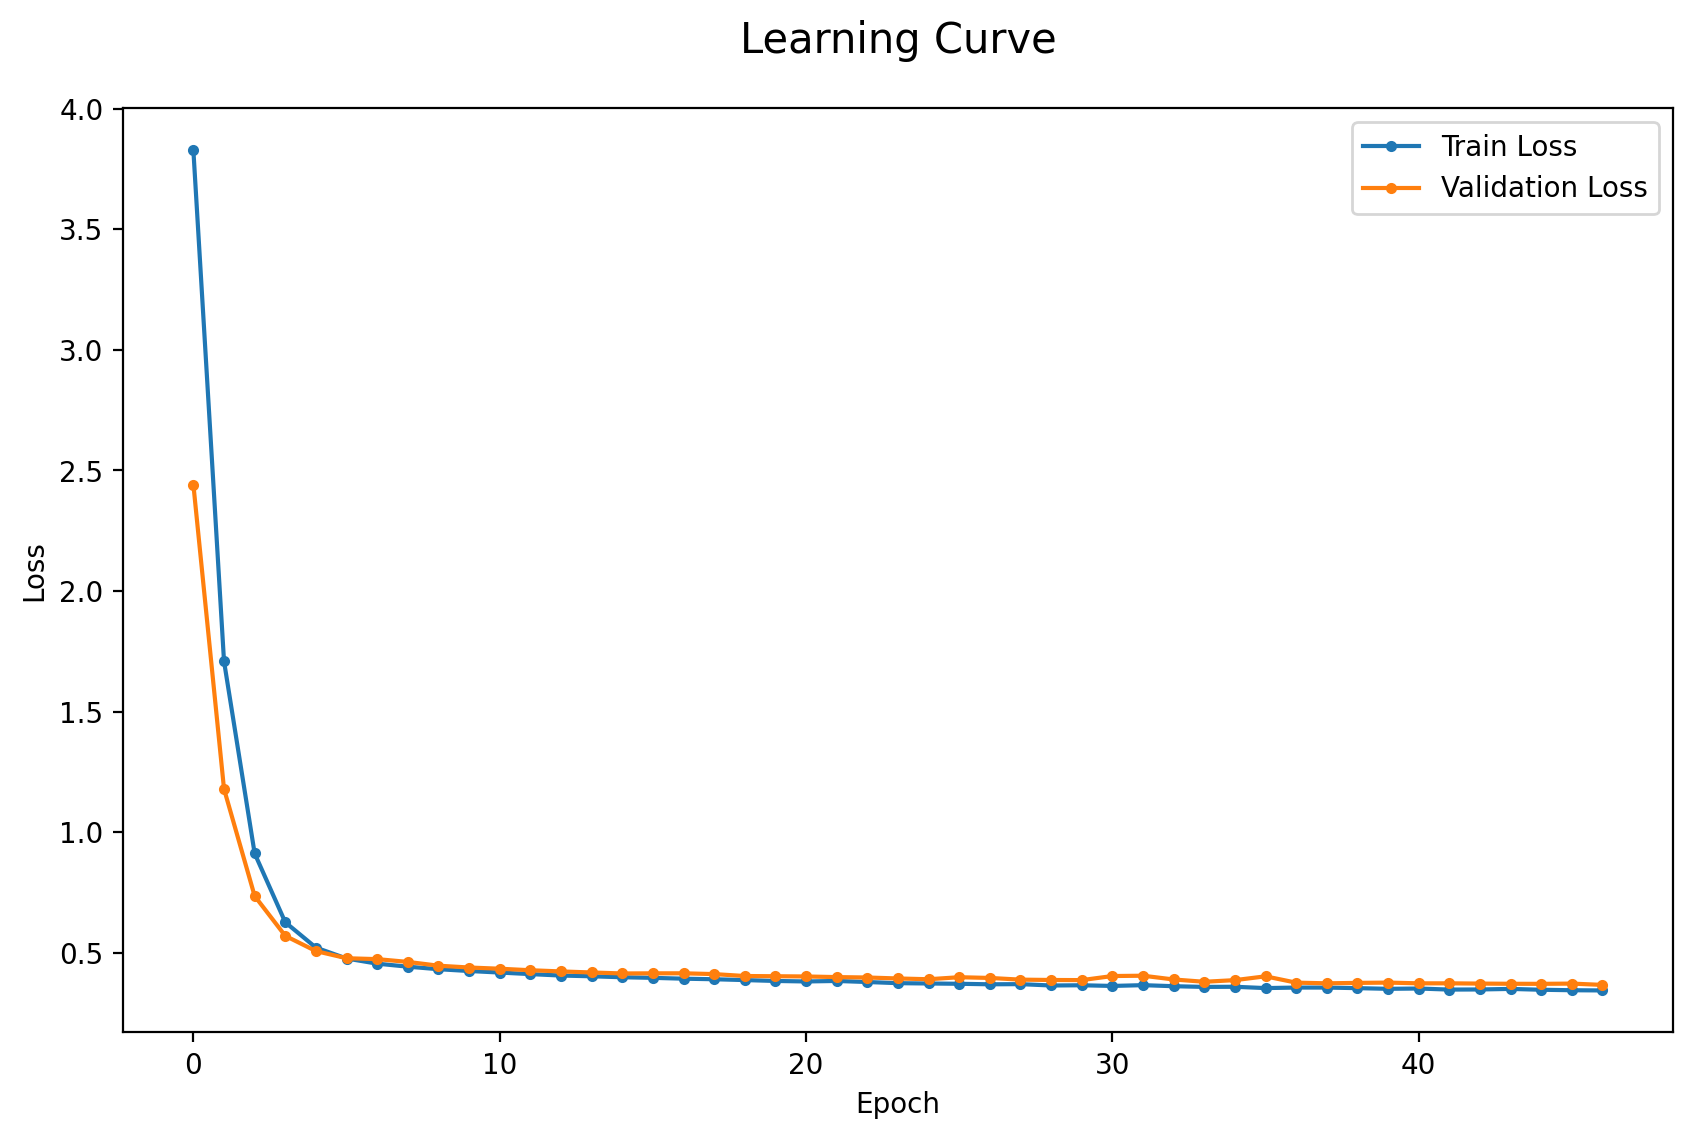

In [90]:
dl_history_plot(hist)

In [91]:
y_pred = model5.predict(x_test)
y_pred =np.where(y_pred >= 0.64, 1,0)
print(classification_report(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       198
           1       0.93      0.88      0.91       199

    accuracy                           0.91       397
   macro avg       0.91      0.91      0.91       397
weighted avg       0.91      0.91      0.91       397

